<h1>My Deep Learning Project: Household Electric Power Consumption Forecasting using LSTM in TensorFlow / Keras</h1>

---

### Project Overview
In this project, I am building a <b>Long Short-Term Memory (LSTM)</b> network in <b>TensorFlow / Keras</b> to forecast daily household electricity consumption (<b>Global Active Power</b> in kilowatts)!

### Key Concepts Covered:
- <b>✅ TensorFlow / Keras Framework</b>: <code>tf.keras.Sequential</code>, <code>LSTM</code>, <code>Dense</code>.
- <b>✅ Dataset Download</b>: Downloaded <code>uciml/electric-power-consumption-data-set</code> via <code>kagglehub</code>.
- <b>✅ Resampling & Normalization</b>: Daily mean active power computation and <code>MinMaxScaler</code> scaling.
- <b>✅ Sliding Window Sequences</b>: 30-day historical lookback sequences ($X_{t-30 \dots t-1} 	o y_t$).
- <b>✅ Forecasting & Metrics</b>: Inverse scaling back to kW, Actual vs. Predicted Power line plot, MSE, RMSE, and MAE evaluation metrics.

---

<h2>Step 1: Importing Libraries & GPU Setup</h2>

In [2]:
# ======================================================
# STEP 1: IMPORTING LIBRARIES
# ======================================================
print("--- STEP 1: IMPORTING LIBRARIES ---")

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")
print("Libraries imported successfully!")

--- STEP 1: IMPORTING LIBRARIES ---
TensorFlow Version: 2.15.0
Libraries imported successfully!


<h2>Step 2: Downloading Dataset via Kagglehub</h2>

In [3]:
# ======================================================
# STEP 2: DOWNLOADING DATASET VIA KAGGLEHUB
# ======================================================
print("--- STEP 2: DOWNLOADING DATASET VIA KAGGLEHUB ---")

import kagglehub

path = kagglehub.dataset_download("uciml/electric-power-consumption-data-set")
print("Path to dataset files:", path)

file_path = os.path.join(path, "household_power_consumption.txt")
raw_df = pd.read_csv(file_path, sep=';', low_memory=False)

print(f"Raw Dataset Shape: {raw_df.shape}")
print(raw_df.head())

--- STEP 2: DOWNLOADING DATASET VIA KAGGLEHUB ---
Path to dataset files: C:\Users\adhik\.cache\kagglehub\datasets\uciml\electric-power-consumption-data-set\versions\1
Raw Dataset Shape: (2075259, 9)
         Date      Time  ... Sub_metering_2 Sub_metering_3
0  16/12/2006  17:24:00  ...          1.000           17.0
1  16/12/2006  17:25:00  ...          1.000           16.0
2  16/12/2006  17:26:00  ...          2.000           17.0
3  16/12/2006  17:27:00  ...          1.000           17.0
4  16/12/2006  17:28:00  ...          1.000           17.0

[5 rows x 9 columns]


<h2>Step 3: Data Cleaning & Daily Resampling</h2>

--- STEP 3: DATA CLEANING & DAILY RESAMPLING ---
Daily Dataset Shape: (1433, 2)
        Date  Global_active_power
0 2006-12-16             3.053475
1 2006-12-17             2.354486
2 2006-12-18             1.530435
3 2006-12-19             1.157079
4 2006-12-20             1.545658


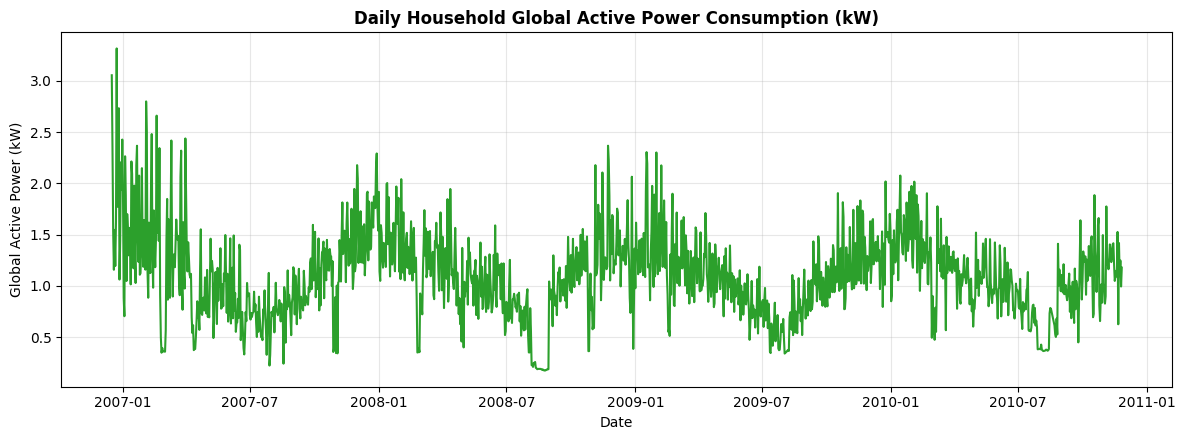

In [4]:
# ======================================================
# STEP 3: DATA CLEANING & DAILY RESAMPLING
# ======================================================
print("--- STEP 3: DATA CLEANING & DAILY RESAMPLING ---")

raw_df['Global_active_power'] = pd.to_numeric(raw_df['Global_active_power'], errors='coerce')
raw_df['Date'] = pd.to_datetime(raw_df['Date'], format='%d/%m/%Y')

daily_df = raw_df.groupby('Date')['Global_active_power'].mean().reset_index()
daily_df = daily_df.dropna().sort_values('Date').reset_index(drop=True)

print(f"Daily Dataset Shape: {daily_df.shape}")
print(daily_df.head())

plt.figure(figsize=(12, 4.5))
plt.plot(daily_df['Date'], daily_df['Global_active_power'], color='#2ca02c', linewidth=1.5)
plt.title("Daily Household Global Active Power Consumption (kW)", fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<h2>Step 4: Scaling & Sequence Creation (80/20 Train-Test Split)</h2>

In [5]:
# ======================================================
# STEP 4: FEATURE SCALING & SEQUENCE CREATION
# ======================================================
print("--- STEP 4: FEATURE SCALING & SEQUENCE CREATION ---")

power_values = daily_df[['Global_active_power']].values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_power = scaler.fit_transform(power_values)

SEQ_LENGTH = 30
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(scaled_power, SEQ_LENGTH)

train_size = int(0.8 * len(X_all))
X_train, y_train = X_all[:train_size], y_all[:train_size]
X_test, y_test = X_all[train_size:], y_all[train_size:]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

--- STEP 4: FEATURE SCALING & SEQUENCE CREATION ---
X_train shape: (1122, 30, 1), y_train shape: (1122, 1)
X_test shape:  (281, 30, 1), y_test shape:  (281, 1)


<h2>Step 5: Building TensorFlow LSTM Architecture</h2>

In [6]:
# ======================================================
# STEP 5: TENSORFLOW LSTM MODEL DEFINITION
# ======================================================
print("--- STEP 5: BUILDING TENSORFLOW LSTM ---")

model_lstm = Sequential([
    LSTM(64, input_shape=(SEQ_LENGTH, 1)),
    Dense(1)
])

model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

print(model_lstm.summary())

--- STEP 5: BUILDING TENSORFLOW LSTM ---
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                16896     
                                                                 
 dense_6 (Dense)             (None, 1)                 65        
                                                                 
Total params: 16961 (66.25 KB)
Trainable params: 16961 (66.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


<h2>Step 6: Training LSTM & Loss Curve</h2>

--- STEP 6: TRAINING LSTM MODEL ---
Epoch 1/35

36/36 [==============================] - 4s 20ms/step - loss: 0.0219
Epoch 2/35

36/36 [==============================] - 1s 29ms/step - loss: 0.0108
Epoch 3/35

36/36 [==============================] - 1s 29ms/step - loss: 0.0107
Epoch 4/35

36/36 [==============================] - 1s 23ms/step - loss: 0.0107
Epoch 5/35

36/36 [==============================] - 1s 26ms/step - loss: 0.0104
Epoch 6/35

36/36 [==============================] - 1s 32ms/step - loss: 0.0106
Epoch 7/35

36/36 [==============================] - 1s 18ms/step - loss: 0.0105
Epoch 8/35

36/36 [==============================] - 1s 26ms/step - loss: 0.0103
Epoch 9/35

36/36 [==============================] - 1s 27ms/step - loss: 0.0101
Epoch 10/35

36/36 [==============================] - 1s 34ms/step - loss: 0.0103
Epoch 11/35

36/36 [==============================] - 1s 34ms/step - loss: 0.0101
Epoch 12/35

36/36 [==============================] - 1s 33ms/step - lo

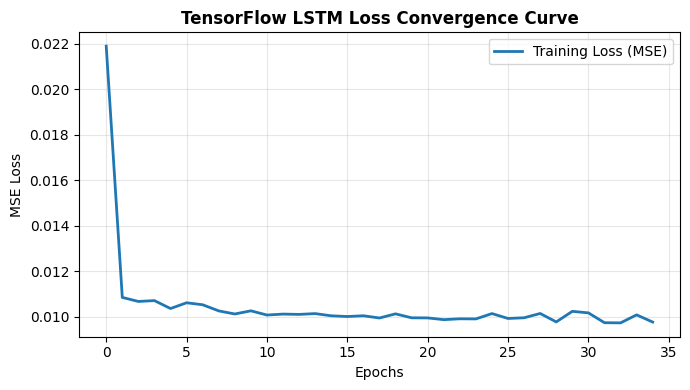

In [7]:
# ======================================================
# STEP 6: TRAINING LSTM MODEL
# ======================================================
print("--- STEP 6: TRAINING LSTM MODEL ---")

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=35,
    batch_size=32,
    verbose=1
)

plt.figure(figsize=(7, 4))
plt.plot(history_lstm.history['loss'], label='Training Loss (MSE)', color='#1f77b4', linewidth=2)
plt.title("TensorFlow LSTM Loss Convergence Curve", fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<h2>Step 7: Test Evaluation & Actual vs Predicted Forecast Plot</h2>

--- STEP 7: TEST EVALUATION & FORECAST PLOT ---
TENSORFLOW LSTM POWER FORECASTING METRICS
  • MSE:  0.0570
  • RMSE: 0.2388 kW
  • MAE:  0.1732 kW


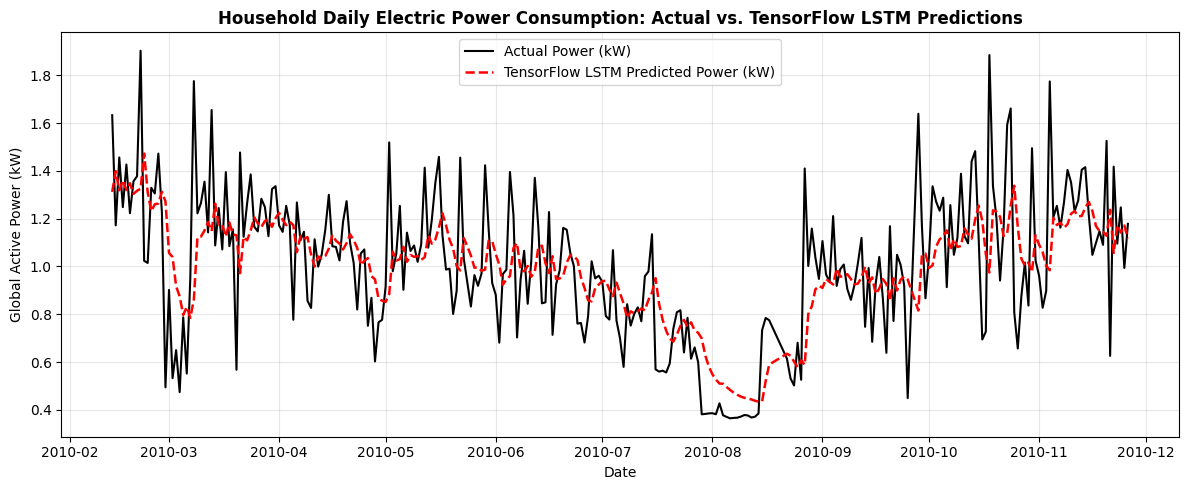

In [8]:
# ======================================================
# STEP 7: TEST EVALUATION & FORECAST PLOT
# ======================================================
print("--- STEP 7: TEST EVALUATION & FORECAST PLOT ---")

test_preds_scaled = model_lstm.predict(X_test, verbose=0)

actual_power = scaler.inverse_transform(y_test)
predicted_power = scaler.inverse_transform(test_preds_scaled)

test_dates = daily_df['Date'].values[-len(actual_power):]

plt.figure(figsize=(12, 5))
plt.plot(test_dates, actual_power, label='Actual Power (kW)', color='black', linewidth=1.5)
plt.plot(test_dates, predicted_power, label='TensorFlow LSTM Predicted Power (kW)', color='red', linestyle='--', linewidth=1.8)
plt.title("Household Daily Electric Power Consumption: Actual vs. TensorFlow LSTM Predictions", fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate Regression Metrics
mse = mean_squared_error(actual_power, predicted_power)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_power, predicted_power)

print("="*55)
print("TENSORFLOW LSTM POWER FORECASTING METRICS")
print("="*55)
print(f"  • MSE:  {mse:.4f}")
print(f"  • RMSE: {rmse:.4f} kW")
print(f"  • MAE:  {mae:.4f} kW")
print("="*55)